# Smart Inference Trigger — Demo

**Ideia:** detectar objetos com a YOLO é caro. Se o frame de agora é quase igual ao anterior, *nada de novo aconteceu* — então não vale rodar a YOLO de novo, reaproveito o resultado anterior.

Uso **visão computacional clássica** (barata) como um **gatilho** que decide quando vale a pena chamar a YOLO (cara).

Este notebook reaproveita as classes do pacote `smart_trigger`:
- `MotionTrigger` (`trigger.py`) — o gatilho de diferença entre frames;
- `Detector` (`detector.py`) — o wrapper da YOLO com cache das últimas caixas.

## 1. Imports e parâmetros

In [1]:
import time

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

from trigger import MotionTrigger
from detector import Detector

In [ ]:
# Fonte: caminho de um video OU 0 para a webcam.
# SOURCE = "videos/ref.mp4"
# SOURCE = 0
# SOURCE = "http://localhost:8080/video"
MODEL = "yolov8m.pt"  # modelo "meio do caminho"

# Parâmetros do gatilho:
MOTION_THRESHOLD = 0.005  # fração da imagem (0-1) que precisa mudar para acionar
DIFF_THRESHOLD = 25       # limiar (0-255) da diferença entre frames
BLUR_KERNEL = 5           # tamanho (impar) do kernel do GaussianBlur

# Limite de frames (protege contra loop infinito da webcam). None = sem limite.
MAX_FRAMES = 300

## 2. Entendendo o gatilho visualmente

Antes de rodar tudo, vamos ver **os 5 passos do gatilho** em dois frames do vídeo: cinza → blur → `absdiff` → `threshold`. Onde houve movimento, a máscara fica branca.

Fracao da imagem que mudou entre os dois frames: 6.07%


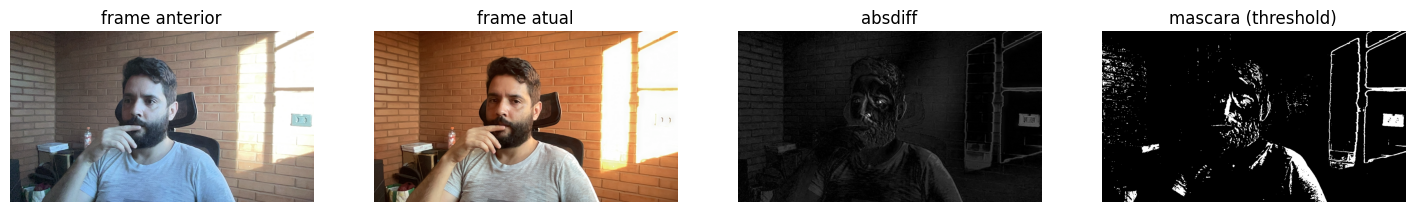

In [3]:
cap = cv2.VideoCapture(SOURCE)
ok1, frame_a = cap.read()
# Pula alguns frames para pegar um par com algum movimento entre eles.
for _ in range(10):
    ok2, frame_b = cap.read()
cap.release()
assert ok1 and ok2, f"Nao consegui ler frames de {SOURCE!r}. Confira o caminho."

k = BLUR_KERNEL
gray_a = cv2.GaussianBlur(cv2.cvtColor(frame_a, cv2.COLOR_BGR2GRAY), (k, k), 0)
gray_b = cv2.GaussianBlur(cv2.cvtColor(frame_b, cv2.COLOR_BGR2GRAY), (k, k), 0)
diff = cv2.absdiff(gray_b, gray_a)
_, mask = cv2.threshold(diff, DIFF_THRESHOLD, 255, cv2.THRESH_BINARY)

score = cv2.countNonZero(mask) / mask.size
print(f"Fracao da imagem que mudou entre os dois frames: {score * 100:.2f}%")

fig, ax = plt.subplots(1, 4, figsize=(18, 4))
ax[0].imshow(cv2.cvtColor(frame_a, cv2.COLOR_BGR2RGB)); ax[0].set_title("frame anterior")
ax[1].imshow(cv2.cvtColor(frame_b, cv2.COLOR_BGR2RGB)); ax[1].set_title("frame atual")
ax[2].imshow(diff, cmap="gray"); ax[2].set_title("absdiff")
ax[3].imshow(mask, cmap="gray"); ax[3].set_title("mascara (threshold)")
for a in ax:
    a.axis("off")
plt.show()

## 3. Loop principal com visualização ao vivo

Para cada frame: pergunto ao `MotionTrigger` se mudou o suficiente. Se sim, rodo a YOLO; se não, reaproveito as últimas caixas. Mostro o frame anotado inline (efeito "flipbook").

> O FPS medido **aqui** inclui o tempo de desenhar a imagem no notebook, então não reflete o custo real da YOLO. O benchmark honesto está na seção 5.

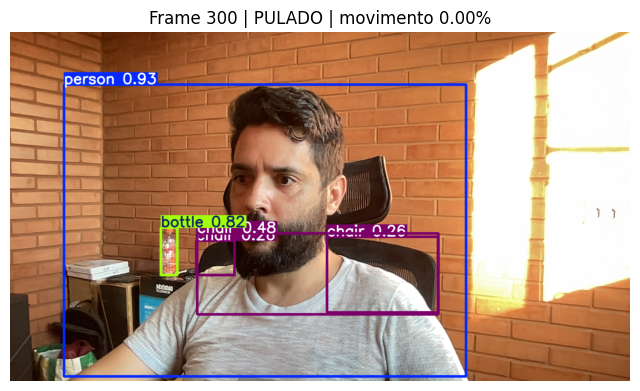

Concluido: 300 frames processados.


In [4]:
detector = Detector(MODEL)
trigger = MotionTrigger(
    diff_threshold=DIFF_THRESHOLD,
    motion_threshold=MOTION_THRESHOLD,
    blur_kernel=BLUR_KERNEL,
)

cap = cv2.VideoCapture(SOURCE)
scores, triggered_flags = [], []
total = triggered = 0

try:
    while True:
        ok, frame = cap.read()
        if not ok or (MAX_FRAMES and total >= MAX_FRAMES):
            break
        total += 1

        result = trigger.evaluate(frame)
        scores.append(result.score)
        triggered_flags.append(result.should_run)

        if result.should_run:
            triggered += 1
            annotated, _ = detector.detect(frame)
        else:
            annotated = detector.last_annotated(frame)  # reusa as ultimas caixas

        clear_output(wait=True)
        plt.figure(figsize=(8, 5))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        status = "ACIONADO" if result.should_run else "PULADO"
        plt.title(f"Frame {total} | {status} | movimento {result.score * 100:.2f}%")
        plt.axis("off")
        plt.show()
finally:
    cap.release()

print(f"Concluido: {total} frames processados.")

## 4. Resumo e linha do tempo do gatilho

Quantos frames foram pulados e em que momentos a YOLO foi acionada (pontos verdes acima da linha de threshold).

Frames processados : 300
Frames com YOLO    : 84
Frames pulados     : 216 (72.0%)


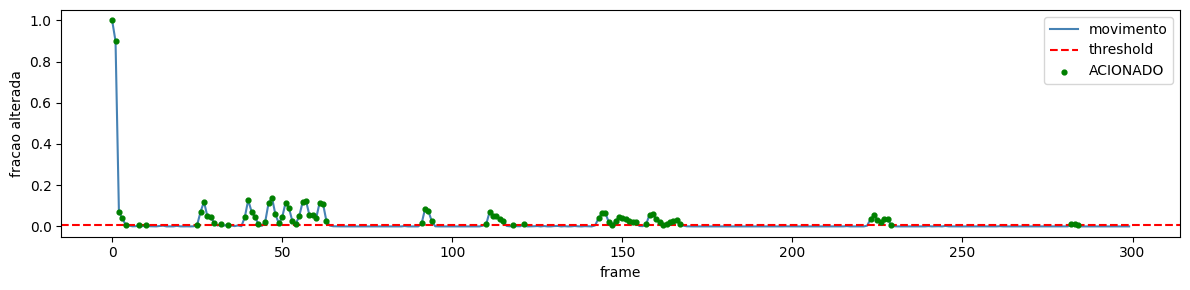

In [5]:
skipped = total - triggered
print(f"Frames processados : {total}")
print(f"Frames com YOLO    : {triggered}")
print(f"Frames pulados     : {skipped} ({skipped / total * 100:.1f}%)")

fired = [i for i, t in enumerate(triggered_flags) if t]
plt.figure(figsize=(12, 3))
plt.plot(scores, label="movimento", color="steelblue")
plt.axhline(MOTION_THRESHOLD, color="red", ls="--", label="threshold")
plt.scatter(fired, [scores[i] for i in fired], color="green", s=12, label="ACIONADO", zorder=3)
plt.xlabel("frame"); plt.ylabel("fracao alterada"); plt.legend(); plt.tight_layout()
plt.show()

## 5. Benchmark: gatilho vs. baseline (FPS honesto)

Roda o vídeo **sem desenhar nada na tela** nos dois modos e compara o FPS. O `baseline` roda a YOLO em todo frame; o `gatilho` só quando há movimento. É a prova da economia (item 2 do roteiro).

In [6]:
def run_benchmark(use_trigger: bool):
    detector = Detector(MODEL)
    trigger = MotionTrigger(
        diff_threshold=DIFF_THRESHOLD,
        motion_threshold=MOTION_THRESHOLD,
        blur_kernel=BLUR_KERNEL,
    )
    cap = cv2.VideoCapture(SOURCE)
    total = triggered = 0
    start = time.perf_counter()
    while True:
        ok, frame = cap.read()
        if not ok or (MAX_FRAMES and total >= MAX_FRAMES):
            break
        total += 1
        run_yolo = True if not use_trigger else trigger.evaluate(frame).should_run
        if run_yolo:
            triggered += 1
            detector.detect(frame)
    cap.release()
    return total, triggered, time.perf_counter() - start


for label, use_trigger in [("BASELINE", False), ("GATILHO ", True)]:
    t, tr, elapsed = run_benchmark(use_trigger)
    print(f"{label} | {t} frames | {tr} com YOLO | {elapsed:5.2f}s | {t / elapsed:5.1f} FPS")

KeyboardInterrupt: 

## 6. Experimentos (extras do roteiro)

Recrie o gatilho com `use_grayscale=False` ou `use_blur=False` e rode a seção 3/4 de novo. Observe:
- **sem grayscale**: compara em 3 canais (mais lento, mais sensível a cor);
- **sem blur**: o ruído do sensor passa a disparar o gatilho à toa (mais frames ACIONADOS sem ninguém se mexer).

```python
trigger = MotionTrigger(use_blur=False)      # teste sem suavização
trigger = MotionTrigger(use_grayscale=False) # teste em BGR
```